In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import lfilter


tau      = 20.0    # membrane time constant, ms
V_target = 10.0    # target mean voltage, mV
dt       = 0.01    # time step, ms
T_sim    = 50000   # total simulation time, ms
T_burn   = 2000    # burnin time to discard, ms
# T_burn discards the initial transient before V reaches steady state.
# otherwise early time points would form bias

# Number of time steps
N_total = int(T_sim / dt)   # 5,000,000 steps
N_burn  = int(T_burn / dt)  # 200,000

# Three cases: each entry is (nu*tau, label)
cases = [
    (2,   'nu*tau = 2'),
    (20,  'nu*tau = 20'),
    (200, 'nu*tau = 200'),
]

results = []

for nu_tau, label in cases:

    nu = nu_tau / tau       # rate in ms^-1. From nu*tau = nu_tau, so nu = nu_tau/tau
    w  = V_target / nu_tau  # step size in mV. From nu*w*tau = 10, so w = 10/(nu*tau)

 
    mean_th = V_target                          # = nu*w*tau = 10 mV always
    var_th  = 50.0 / nu_tau                    
    skew_th = 2*np.sqrt(2) / (3*np.sqrt(nu_tau))  # from part (c)


    # At each time step, an event probability nu*dt (Poisson ).
    
    spikes = (np.random.rand(N_total) < nu * dt).astype(float) * w

  
    alpha = 1.0 - dt / tau          # decay factor per step: 1 - 0.01/20 = 0.9995
    V = lfilter([1.0], [1.0, -alpha], spikes)
    # lfilter([b0], [1, -a1], x) computes: y[n] = b0*x[n] + a1*y[n-1]
    # b0=1, a1=alpha, V[n] = spikes[n] + alpha*V[n-1]  

    
    V = V[N_burn:]

    
    mean_s = np.mean(V)       # sample mean
    var_s  = np.var(V)        # sample variance (numpy uses N denominator)
    skew_s = stats.skew(V)    # sample skewness = (1/N)*sum((V-mean)^3) / std^3

    results.append(dict(
        label=label, nu_tau=nu_tau,
        nu_hz=nu*1000, w=w,
        mean_th=mean_th, var_th=var_th, skew_th=skew_th,
        mean_s=mean_s, var_s=var_s, skew_s=skew_s,
        V=V
    ))



Case           |  Mean th  Mean sim |  Var th  Var sim |  Skew th  Skew sim
---------------------------------------------------------------------------
nu*tau = 2     |   10.000     9.935 |  25.000   24.244 |   0.6667    0.6400
nu*tau = 20    |   10.000    10.001 |   2.500    2.415 |   0.2108    0.2113
nu*tau = 200   |   10.000    10.019 |   0.250    0.227 |   0.0667    0.0103


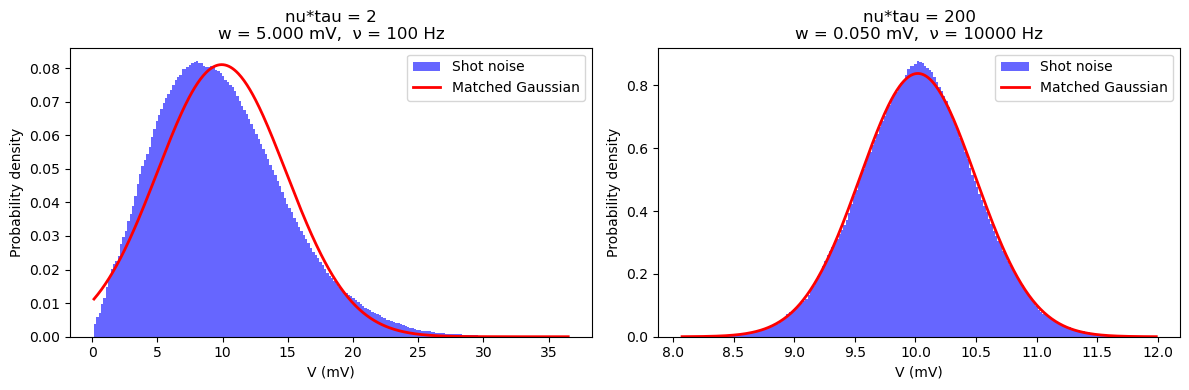

In [4]:
#Table
print(f"\n{'Case':<14} | {'Mean th':>8} {'Mean sim':>9} | {'Var th':>7} {'Var sim':>8} | {'Skew th':>8} {'Skew sim':>9}")
print("-" * 75)
for r in results:
    print(f"{r['label']:<14} | {r['mean_th']:>8.3f} {r['mean_s']:>9.3f} | "
          f"{r['var_th']:>7.3f} {r['var_s']:>8.3f} | "
          f"{r['skew_th']:>8.4f} {r['skew_s']:>9.4f}")


#plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, r in zip(axes, [results[0], results[2]]):
    V_data = r['V']

    # Histogram of the simulated voltage
    ax.hist(V_data, bins=200, density=True, alpha=0.6,
            color='blue', label='Shot noise')

    x = np.linspace(V_data.min(), V_data.max(), 500)
    gauss = stats.norm.pdf(x, loc=r['mean_s'], scale=np.sqrt(r['var_s']))
    ax.plot(x, gauss, 'r-', lw=2, label='Matched Gaussian')

    ax.set_xlabel('V (mV)')
    ax.set_ylabel('Probability density')
    ax.set_title(f"{r['label']}\nw = {r['w']:.3f} mV,  ν = {r['nu_hz']:.0f} Hz")
    ax.legend()

plt.tight_layout()
plt.savefig('prob4d.png', dpi=150)
plt.show()